In [ ]:
!pip install scikit-survival opacus torch panda matplotlib seaborn
!pip install numpy==1.24.3 --force-reinstall

  Preparing metadata (setup.py) ... done
  Created wheel for panda: filename=panda-0.3.1-py3-none-any.whl size=7239 sha256=9ab5788851e8b2b63b289e93f7a3f8c1c402190e30ab84d0a777382ef5f32e8f
  Stored in directory: /root/.cache/pip/wheels/df/5c/39/36f8dae25a1e88d6ec4411dec4a143781e64fdff6897758eec
Successfully built panda
  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 w

In [ ]:
import numpy as np
import pandas as pd
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, brier_score
from opacus import PrivacyEngine
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
import kagglehub

path = kagglehub.dataset_download("raghadalharbi/breast-cancer-gene-expression-profiles-metabric")

print("Path to dataset files:", path)

100%|██████████| 2.72M/2.72M [00:00<00:00, 4.35MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric/versions/1


In [ ]:
import os
import pandas as pd

data_path = "/root/.cache/kagglehub/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric/versions/1"

df = pd.read_csv(os.path.join(data_path, "METABRIC_RNA_Mutation.csv"))
df.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


# Data Preprocessing

In [ ]:
np.random.seed(42)

# Step 1: Define Survival and Clinical Columns
survival_time_col = 'overall_survival_months'
event_col = 'overall_survival'
clinical_features = [
    # Numerical
    'age_at_diagnosis', 'tumor_size', 'lymph_nodes_examined_positive',
    'neoplasm_histologic_grade', 'nottingham_prognostic_index', 'mutation_count',
    'chemotherapy', 'hormone_therapy', 'radio_therapy',
    # Categorical
    'type_of_breast_surgery', 'cancer_type_detailed', 'cellularity',
    'pam50_+_claudin-low_subtype', 'er_status', 'her2_status',
    'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'integrative_cluster'
]

# Check available features
available_features = [col for col in clinical_features if col in df.columns]
missing_features = [col for col in clinical_features if col not in df.columns]
print("Available Clinical Features:", available_features)
print("Missing Clinical Features:", missing_features)

Available Clinical Features: ['age_at_diagnosis', 'tumor_size', 'lymph_nodes_examined_positive', 'neoplasm_histologic_grade', 'nottingham_prognostic_index', 'mutation_count', 'chemotherapy', 'hormone_therapy', 'radio_therapy', 'type_of_breast_surgery', 'cancer_type_detailed', 'cellularity', 'pam50_+_claudin-low_subtype', 'er_status', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'integrative_cluster']
Missing Clinical Features: []



Columns with >50% Missing Values: []

Unnecessary Columns: ['frmd3_mut', 'gpr32_mut', 'map3k13', 'fancd2_mut', 'rbpj', 'dtx3', 'npnt_mut', 'gldc_mut', 'egfr_mut', 'fgf2', 'sbno1', 'hsd3b2', 'jak1_mut', 'bcas3', 'rassf1', 'frmd3', 'cyp21a2', 'setd1a_mut', 'prkcq_mut', 'asxl2_mut', 'palld', 'mtap', 'cdk1', 'fbxw7_mut', 'cdkn1a', 'hsd17b8', 'casp3', 'flt3', 'apaf1', 'nt5e', 'smarcd1', 'thsd7a', 'cdk2', 'map2k4_mut', 'flt3_mut', 'notch1', 'akt1', 'maml3', 'bap1', 'lamb3', 'eif4ebp1', 'lifr', 'sbno1_mut', 'ccnd3_mut', 'wfdc2', 'er_status_measured_by_ihc', 'hes1', 'hes6', 'aff2', 'rad51c', 'hdac2', 'map3k1', 'prkci', 'cdkn1b', 'map2k2', 'kmt2c', 'casp6', 'cdk4', 'foxo3', 'hsd3b7', 'dll4', 'gata3', 'clk3_mut', 'lama2', 'nek1_mut', 'twist1', 'lipi', 'col22a1', 'bmp15', 'col12a1', 'syne1_mut', 'cyp3a43', 'arid5b', 'birc6', 'ugt2b7', 'ahnak2', 'myo1a', 'acvr1b', 'mlh1', 'mmp7', 'shank2_mut', 'cyp11b2', 'dll1', 'stmn2_mut', 'nf2_mut', 'hey1', 'itgb3', 'clk3', 'braf_mut', 'ptpn22', 'rfng', 'bmp5'

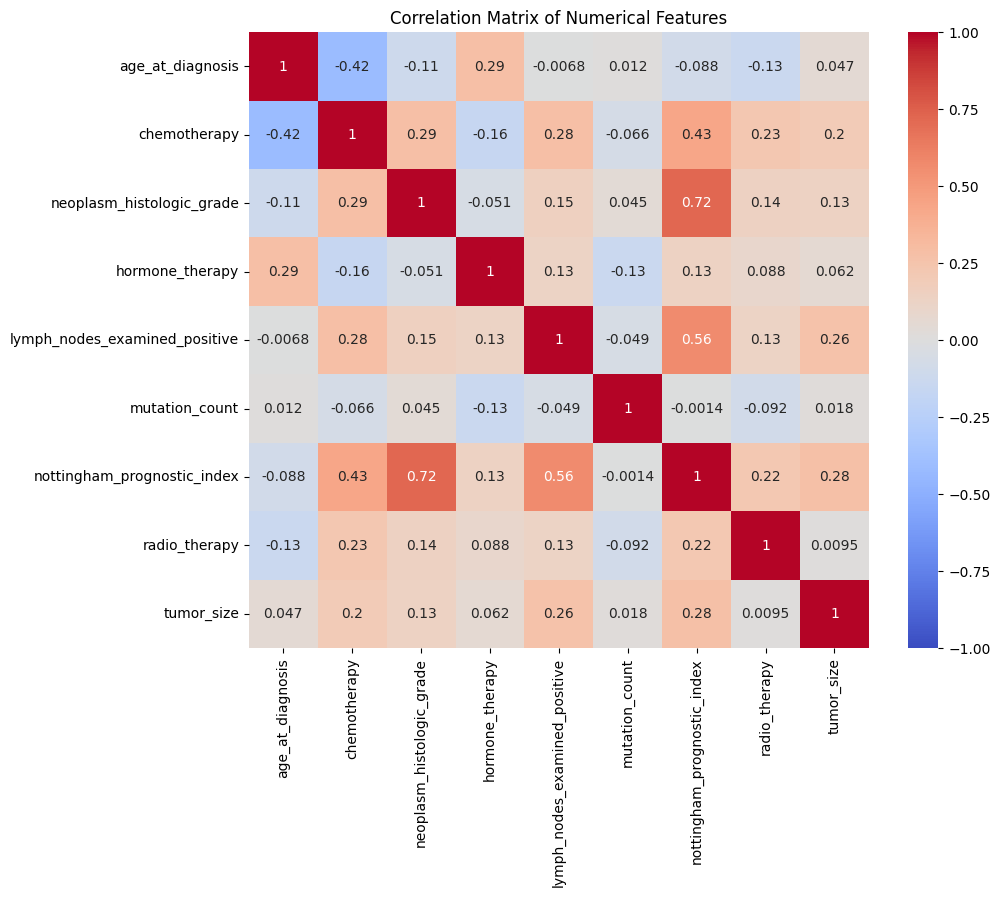


Highly Correlated Pairs (>0.6):
neoplasm_histologic_grade - nottingham_prognostic_index: 0.72

Dataset Shape After Correlation-Based Drops: (1904, 19)
Remaining Columns: ['age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'er_status', 'neoplasm_histologic_grade', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'lymph_nodes_examined_positive', 'mutation_count', 'overall_survival_months', 'overall_survival', 'radio_therapy', 'tumor_size']

Reduced dataset saved as 'metabric_reduced.csv'.


In [ ]:

# Step 2: Remove Unnecessary Columns
#Identify columns with >50% missing values
missing_percent = df.isnull().sum() / len(df) * 100
high_missing_cols = missing_percent[missing_percent > 50].index
print("\nColumns with >50% Missing Values:", list(high_missing_cols))

# Define necessary columns
necessary_columns = [survival_time_col, event_col] + available_features
all_columns = set(df.columns)
unnecessary_columns = all_columns - set(necessary_columns)
print("\nUnnecessary Columns:", list(unnecessary_columns))

# Drop unnecessary and high-missing columns
drop_columns = list(high_missing_cols) + list(unnecessary_columns)
drop_columns = list(set(drop_columns))  # Remove duplicates
drop_columns = [col for col in drop_columns if col not in [survival_time_col, event_col]]
data_reduced = df.drop(columns=drop_columns)
print("\nReduced Dataset Shape:", data_reduced.shape)
print("Remaining Columns:", list(data_reduced.columns))

# Step 3: Correlation Analysis for Redundant Features
numerical_cols = data_reduced.select_dtypes(include=['float64', 'int64']).columns.drop([survival_time_col, event_col], errors='ignore')
print("\nNumerical Features for Correlation:", list(numerical_cols))
corr_matrix = data_reduced[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('correlation_matrix.png')
plt.show()

# Identify highly correlated pairs (>0.8)
high_corr_pairs = []
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.6:
            high_corr_pairs.append((numerical_cols[i], numerical_cols[j], corr_matrix.iloc[i, j]))
print("\nHighly Correlated Pairs (>0.6):")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

# Step 4: Select and Drop Features Based on Correlation
high_corr_to_drop = ['nottingham_prognostic_index']
df_reduced = data_reduced.drop(columns=high_corr_to_drop) # Assign data_reduced to df_reduced before dropping columns
print("\nDataset Shape After Correlation-Based Drops:", df_reduced.shape)
print("Remaining Columns:", list(df_reduced.columns))

df_reduced.to_csv('metabric_reduced.csv', index=False)
print("\nReduced dataset saved as 'metabric_reduced.csv'.")


# Baseline Model

In [ ]:
!pip install scikit-survival pandas numpy scikit-learn --quiet

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Step 1: Load and Preprocess Data from metabric_reduced.csv
df = pd.read_csv('metabric_reduced.csv')

X = df.drop(columns=['overall_survival_months', 'overall_survival'])
y = df[['overall_survival', 'overall_survival_months']]

y = y.astype({'overall_survival': 'int', 'overall_survival_months': 'float'})
if not (y['overall_survival'].isin([0, 1]).all() and y['overall_survival_months'].notna().all()):
    raise ValueError("Survival data contains invalid values.")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

# One-hot encode categorical variables
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_cats = encoder.fit_transform(X[categorical_cols])
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)
X_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_cat_cols, index=X.index)

# Combine encoded categoricals with numerical columns
X_processed = pd.concat([X[numerical_cols], X_encoded_cats], axis=1)

# Drop columns with near-zero variance (to avoid singular matrix)
low_var_cols = X_processed.columns[X_processed.std() < 1e-5]
X_processed.drop(columns=low_var_cols, inplace=True)

# Impute missing values
for col in X_processed.columns:
    if X_processed[col].dtype in ['float64', 'int64']:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())
    else:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mode()[0])

print("Processed data shape:", X_processed.shape)
print("Missing values:", X_processed.isnull().sum().sum())
print("Inf values:", np.isinf(X_processed).sum().sum())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_processed[numerical_cols] = scaler.fit_transform(X_processed[numerical_cols])

corr_matrix = X_processed.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.999)]
X_processed.drop(columns=to_drop, inplace=True)

print(f"Final shape after dropping correlated columns: {X_processed.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
y_train_struct = np.array([(e == 1, t) for e, t in zip(y_train['overall_survival'], y_train['overall_survival_months'])], dtype=[('event', bool), ('time', float)])
y_test_struct = np.array([(e == 1, t) for e, t in zip(y_test['overall_survival'], y_test['overall_survival_months'])], dtype=[('event', bool), ('time', float)])

print("Fitting CoxPH model...")
coxph = CoxPHSurvivalAnalysis()
try:
    coxph.fit(X_train, y_train_struct)
    print("Model fitted successfully.")
except Exception as e:
    print("Model fitting failed:", str(e))
    raise

risk_scores = coxph.predict(X_test)
c_index = concordance_index_censored(y_test_struct['event'], y_test_struct['time'], risk_scores)[0]
print(f"\n Concordance Index (C-index) on Test Set: {c_index:.4f}")

print("\n Top 10 CoxPH Coefficients (sorted by magnitude):")
coefs = pd.Series(coxph.coef_, index=X_train.columns)
coefs_sorted = coefs.abs().sort_values(ascending=False).head(10)
print(coefs.loc[coefs_sorted.index])


Processed data shape: (1904, 46)
Missing values: 0
Inf values: 0
Final shape after dropping correlated columns: (1904, 41)
Fitting CoxPH model...
Model fitted successfully.

 Concordance Index (C-index) on Test Set: 0.6219

 Top 10 CoxPH Coefficients (sorted by magnitude):
cancer_type_detailed_Metaplastic Breast Cancer                   -122.564205
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma   -110.052111
cancer_type_detailed_Breast Invasive Lobular Carcinoma           -109.701213
cancer_type_detailed_Breast Invasive Ductal Carcinoma            -109.598857
cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma    -109.426196
tumor_other_histologic_subtype_Other                             -109.274883
cancer_type_detailed_nan                                         -109.063314
pam50_+_claudin-low_subtype_NC                                    -13.272018
integrative_cluster_2                                              -0.932298
tumor_other_histologic_subtype_Me

In [ ]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

coxnet = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=10000)
print("Fitting Regularized Cox model (ElasticNet)...")
try:
    coxnet.fit(X_train, y_train_struct)
    print("Model fitted successfully.")
except Exception as e:
    print("Model fitting failed:", str(e))
    raise

risk_scores = coxnet.predict(X_test)
c_index = concordance_index_censored(y_test_struct['event'], y_test_struct['time'], risk_scores)[0]
print(f"\nRegularized Cox Model C-index: {c_index:.4f}")


final_coefs = coxnet.coef_[:, -1]

coefs = pd.Series(final_coefs, index=X_train.columns)

nonzero_coefs = coefs[coefs != 0].sort_values(key=abs, ascending=False)
print("\n Top 10 Features (non-zero coefficients):")
print(nonzero_coefs.head(10))



Fitting Regularized Cox model (ElasticNet)...
Model fitted successfully.

Regularized Cox Model C-index: 0.6246

 Top 10 Features (non-zero coefficients):
tumor_other_histologic_subtype_Medullary                         -0.625986
integrative_cluster_2                                            -0.584708
tumor_other_histologic_subtype_Tubular/ cribriform               -0.459500
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma   -0.408636
integrative_cluster_6                                            -0.315102
type_of_breast_surgery_MASTECTOMY                                -0.286507
chemotherapy                                                      0.264728
hormone_therapy                                                   0.256794
cancer_type_detailed_nan                                          0.210067
cellularity_Low                                                   0.192358
dtype: float64


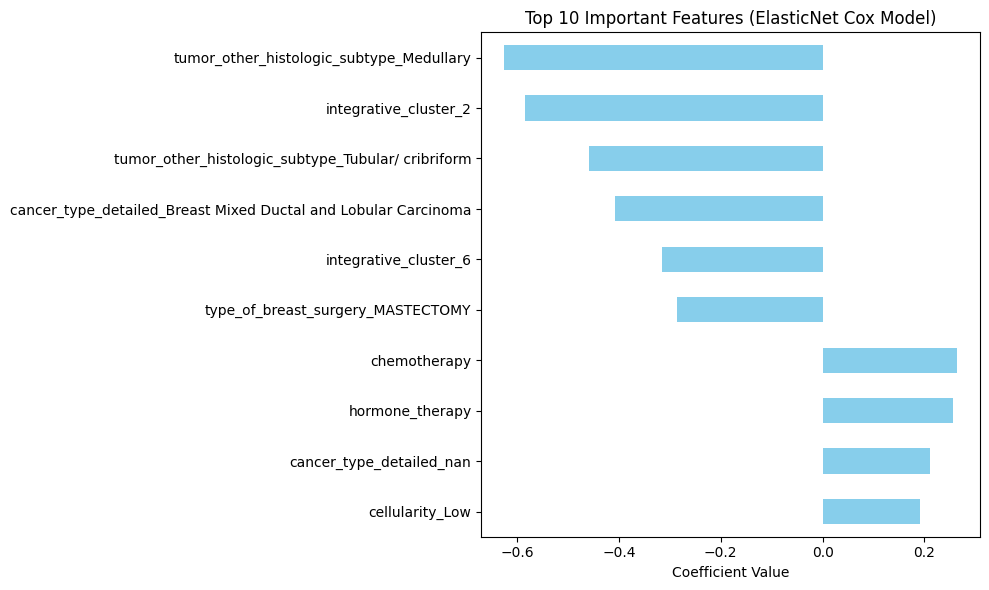

In [ ]:
import matplotlib.pyplot as plt

coefs = pd.Series(coxnet.coef_[:, -1], index=X_train.columns)

nonzero_coefs = coefs[coefs != 0].sort_values(key=abs, ascending=False).head(10)


plt.figure(figsize=(10, 6))
nonzero_coefs.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (ElasticNet Cox Model)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


In [ ]:
!pip install scikit-survival pandas numpy scikit-learn torch opacus

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sksurv.metrics import concordance_index_censored
import torch
import torch.nn as nn
import torch.optim as optim
from opacus import PrivacyEngine
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv('metabric_reduced.csv')

X = df.drop(columns=['overall_survival_months', 'overall_survival'])
y = df[['overall_survival', 'overall_survival_months']]

y = y.astype({'overall_survival': 'int', 'overall_survival_months': 'float'})
if not (y['overall_survival'].isin([0, 1]).all() and y['overall_survival_months'].notna().all()):
    raise ValueError("Survival data contains invalid values.")

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_cats = encoder.fit_transform(X[categorical_cols])
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)
X_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_cat_cols, index=X.index)

X_processed = pd.concat([X[numerical_cols], X_encoded_cats], axis=1)

for col in X_processed.columns:
    if X_processed[col].dtype in ['float64', 'int64']:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())
    else:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mode()[0])

print("X_processed shape:", X_processed.shape)
print("NaN check in X_processed:", X_processed.isnull().sum().sum())
print("Inf check in X_processed:", np.isinf(X_processed).sum().sum())
if X_processed.isnull().sum().sum() > 0 or np.isinf(X_processed).sum().sum() > 0:
    raise ValueError("X_processed contains NaNs or Infs after imputation.")

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_event = torch.tensor(y_train['overall_survival'].values, dtype=torch.float32)
y_train_time = torch.tensor(y_train['overall_survival_months'].values, dtype=torch.float32)
y_test_event = torch.tensor(y_test['overall_survival'].values, dtype=torch.float32)
y_test_time = torch.tensor(y_test['overall_survival_months'].values, dtype=torch.float32)

class CoxPHModel(nn.Module):
    def __init__(self, input_dim):
        super(CoxPHModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)

    def forward(self, x):
        return self.linear(x)

def cox_ph_loss(risk_scores, events, times):
    idx = torch.argsort(times, descending=True)
    risk_scores = risk_scores[idx]
    events = events[idx]
    log_risk = torch.logcumsumexp(risk_scores, dim=0)
    loss = -torch.sum(events * (risk_scores - log_risk))
    return loss / events.sum()

model = CoxPHModel(input_dim=X_train_tensor.shape[1])
optimizer = optim.SGD(model.parameters(), lr=0.01)

privacy_engine = PrivacyEngine()
delta = 1e-5
noise_multiplier = 1.0
max_grad_norm = 1.0

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_event, y_train_time)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=noise_multiplier,
    max_grad_norm=max_grad_norm,
)

model.train()
num_epochs = 100
for epoch in range(num_epochs):
    for batch_x, batch_event, batch_time in train_loader:
        optimizer.zero_grad()
        risk_scores = model(batch_x).squeeze()
        loss = cox_ph_loss(risk_scores, batch_event, batch_time)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

epsilon = privacy_engine.accountant.get_epsilon(delta=delta)
print(f"\nDP-SGD (ε, δ)-DP: ({epsilon:.2f}, {delta})")

model.eval()
with torch.no_grad():
    risk_scores = model(X_test_tensor).squeeze().numpy()

c_index = concordance_index_censored(y_test_event.numpy().astype(bool), y_test_time.numpy(), risk_scores)[0]
print(f"\nDP-SGD Cox Model C-index: {c_index:.4f}")
print(f"Baseline C-index (CoxnetSurvivalAnalysis): 0.6258")
print(f"Utility Loss due to DP: {(0.6258 - c_index):.4f}")

X_processed shape: (1904, 46)
NaN check in X_processed: 0
Inf check in X_processed: 0
Epoch [20/100], Loss: 4.1764
Epoch [40/100], Loss: 4.2478
Epoch [60/100], Loss: 3.5089
Epoch [80/100], Loss: 4.0340
Epoch [100/100], Loss: 3.0396

DP-SGD (ε, δ)-DP: (9.65, 1e-05)

DP-SGD Cox Model C-index: 0.5713
Baseline C-index (CoxnetSurvivalAnalysis): 0.6258
Utility Loss due to DP: 0.0545


In [ ]:
!pip install scikit-survival pandas numpy scikit-learn torch

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sksurv.metrics import concordance_index_censored
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv('metabric_reduced.csv')
X = df.drop(columns=['overall_survival_months', 'overall_survival'])
y = df[['overall_survival', 'overall_survival_months']]

y = y.astype({'overall_survival': 'int', 'overall_survival_months': 'float'})
if not (y['overall_survival'].isin([0, 1]).all() and y['overall_survival_months'].notna().all()):
    raise ValueError("Survival data contains invalid values.")

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_cats = encoder.fit_transform(X[categorical_cols])
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)
X_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_cat_cols, index=X.index)

X_processed = pd.concat([X[numerical_cols], X_encoded_cats], axis=1)

for col in X_processed.columns:
    if X_processed[col].dtype in ['float64', 'int64']:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())
    else:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mode()[0])

scaler = StandardScaler()
X_processed = pd.DataFrame(scaler.fit_transform(X_processed), columns=X_processed.columns, index=X_processed.index)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_event = torch.tensor(y_train['overall_survival'].values, dtype=torch.float32)
y_train_time = torch.tensor(y_train['overall_survival_months'].values, dtype=torch.float32)
y_test_event = torch.tensor(y_test['overall_survival'].values, dtype=torch.float32)
y_test_time = torch.tensor(y_test['overall_survival_months'].values, dtype=torch.float32)

class CoxPHModel(nn.Module):
    def __init__(self, input_dim):
        super(CoxPHModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)

    def forward(self, x):
        return self.linear(x)

def cox_ph_loss(risk_scores, events, times):
    idx = torch.argsort(times, descending=True)
    risk_scores = risk_scores[idx]
    events = events[idx]
    risk_scores = torch.clamp(risk_scores, -10, 10)
    log_risk = torch.logcumsumexp(risk_scores, dim=0)
    loss = -torch.sum(events * (risk_scores - log_risk))
    if events.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    return loss / events.sum()

k = 5
n_train = len(X_train)
partition_size = n_train // k
teachers = []

for i in range(k):
    start_idx = i * partition_size
    end_idx = (i + 1) * partition_size if i < k - 1 else n_train
    X_subset = X_train_tensor[start_idx:end_idx]
    event_subset = y_train_event[start_idx:end_idx]
    time_subset = y_train_time[start_idx:end_idx]

    teacher = CoxPHModel(input_dim=X_train_tensor.shape[1])
    optimizer = optim.SGD(teacher.parameters(), lr=0.005)
    teacher.train()
    for epoch in range(30):
        optimizer.zero_grad()
        risk_scores = teacher(X_subset).squeeze()
        loss = cox_ph_loss(risk_scores, event_subset, time_subset)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(teacher.parameters(), max_norm=1.0)
        optimizer.step()
    teachers.append(teacher)

epsilon = 1.0
sensitivity = 1.0
scale = sensitivity / epsilon

teacher_preds = []
for teacher in teachers:
    teacher.eval()
    with torch.no_grad():
        preds = teacher(X_test_tensor).squeeze().numpy()
        preds = np.clip(preds, -10, 10)
        if np.any(np.isnan(preds)):
            raise ValueError("Teacher predictions contain NaN.")
    teacher_preds.append(preds)

teacher_preds = np.array(teacher_preds)

aggregated_preds = np.mean(teacher_preds, axis=0)
noise = np.random.laplace(loc=0, scale=scale, size=aggregated_preds.shape)
noisy_preds = aggregated_preds + noise
noisy_preds = np.clip(noisy_preds, -10, 10)

student = CoxPHModel(input_dim=X_train_tensor.shape[1])
optimizer = optim.SGD(student.parameters(), lr=0.005)  1
student.train()
noisy_preds_tensor = torch.tensor(noisy_preds, dtype=torch.float32)

for epoch in range(30):
    optimizer.zero_grad()
    student_risk_scores = student(X_test_tensor).squeeze()
    loss = nn.MSELoss()(student_risk_scores, noisy_preds_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

student.eval()
with torch.no_grad():
    risk_scores = student(X_test_tensor).squeeze().numpy()
    if np.any(np.isnan(risk_scores)):
        raise ValueError("Student risk scores contain NaN.")

c_index = concordance_index_censored(y_test_event.numpy().astype(bool), y_test_time.numpy(), risk_scores)[0]
print(f"\nPATE Cox Model C-index: {c_index:.4f}")
print(f"Baseline C-index (CoxnetSurvivalAnalysis): 0.6258")
print(f"Utility Loss due to PATE: {(0.6258 - c_index):.4f}")
print(f"PATE (ε, δ)-DP: ({epsilon:.2f}, 1e-5)")


PATE Cox Model C-index: 0.5487
Baseline C-index (CoxnetSurvivalAnalysis): 0.6258
Utility Loss due to PATE: 0.0771
PATE (ε, δ)-DP: (1.00, 1e-5)


In [ ]:
%pip install numpy==1.24.3 --force-reinstall
%pip install --upgrade pandas scikit-learn scikit-survival

  Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.3 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.3 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.3 which is incompatible.
blosc2 3.3.1 requires numpy>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sksurv.metrics import concordance_index_censored
import torch
import torch.nn as nn
import torch.optim as optim
from opacus import PrivacyEngine
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv('metabric_reduced.csv')
X = df.drop(columns=['overall_survival_months', 'overall_survival'])
y = df[['overall_survival', 'overall_survival_months']]

y = y.astype({'overall_survival': 'int', 'overall_survival_months': 'float'})
if not (y['overall_survival'].isin([0, 1]).all() and y['overall_survival_months'].notna().all()):
    raise ValueError("Survival data contains invalid values.")

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoded_cats = encoder.fit_transform(X[categorical_cols])
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)
X_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_cat_cols, index=X.index)

X_processed = pd.concat([X[numerical_cols], X_encoded_cats], axis=1)

for col in X_processed.columns:
    if X_processed[col].dtype in ['float64', 'int64']:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())
    else:
        X_processed[col] = X_processed[col].fillna(X_processed[col].mode()[0])

scaler = StandardScaler()
X_processed = pd.DataFrame(scaler.fit_transform(X_processed), columns=X_processed.columns, index=X_processed.index)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_event = torch.tensor(y_train['overall_survival'].values, dtype=torch.float32)
y_train_time = torch.tensor(y_train['overall_survival_months'].values, dtype=torch.float32)
y_test_event = torch.tensor(y_test['overall_survival'].values, dtype=torch.float32)
y_test_time = torch.tensor(y_test['overall_survival_months'].values, dtype=torch.float32)

class CoxPHModel(nn.Module):
    def __init__(self, input_dim):
        super(CoxPHModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1, bias=False)

    def forward(self, x):
        return self.linear(x)

def cox_ph_loss(risk_scores, events, times):
    idx = torch.argsort(times, descending=True)
    risk_scores = risk_scores[idx]
    events = events[idx]
    risk_scores = torch.clamp(risk_scores, -10, 10)
    log_risk = torch.logcumsumexp(risk_scores, dim=0)
    loss = -torch.sum(events * (risk_scores - log_risk))
    if events.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    return loss / events.sum()

model = CoxPHModel(input_dim=X_train_tensor.shape[1])
optimizer = optim.SGD(model.parameters(), lr=0.005)

privacy_engine = PrivacyEngine()
delta = 1e-5
rho = 0.5
noise_multiplier = 1.0
max_grad_norm = 1.0

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_event, y_train_time)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=noise_multiplier,
    max_grad_norm=max_grad_norm,
)

model.train()
num_epochs = 100
for epoch in range(num_epochs):
    for batch_x, batch_event, batch_time in train_loader:
        optimizer.zero_grad()
        risk_scores = model(batch_x).squeeze()
        loss = cox_ph_loss(risk_scores, batch_event, batch_time)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

epsilon = privacy_engine.accountant.get_epsilon(delta=delta)
print(f"\nZCDP (ε, δ)-DP: ({epsilon:.2f}, {delta}) (approximated from ρ={rho})")

model.eval()
with torch.no_grad():
    risk_scores = model(X_test_tensor).squeeze().numpy()
    if np.any(np.isnan(risk_scores)):
        raise ValueError("ZCDP risk scores contain NaN.")

c_index = concordance_index_censored(y_test_event.numpy().astype(bool), y_test_time.numpy(), risk_scores)[0]
print(f"\nZCDP Cox Model C-index: {c_index:.4f}")
print(f"Baseline C-index (CoxnetSurvivalAnalysis): 0.6258")
print(f"Utility Loss due to ZCDP: {(0.6258 - c_index):.4f}")

Epoch [20/100], Loss: 2.0430
Epoch [40/100], Loss: 2.3144
Epoch [60/100], Loss: 2.0383
Epoch [80/100], Loss: 1.6516
Epoch [100/100], Loss: 1.8681

ZCDP (ε, δ)-DP: (9.65, 1e-05) (approximated from ρ=0.5)

ZCDP Cox Model C-index: 0.5909
Baseline C-index (CoxnetSurvivalAnalysis): 0.6258
Utility Loss due to ZCDP: 0.0349


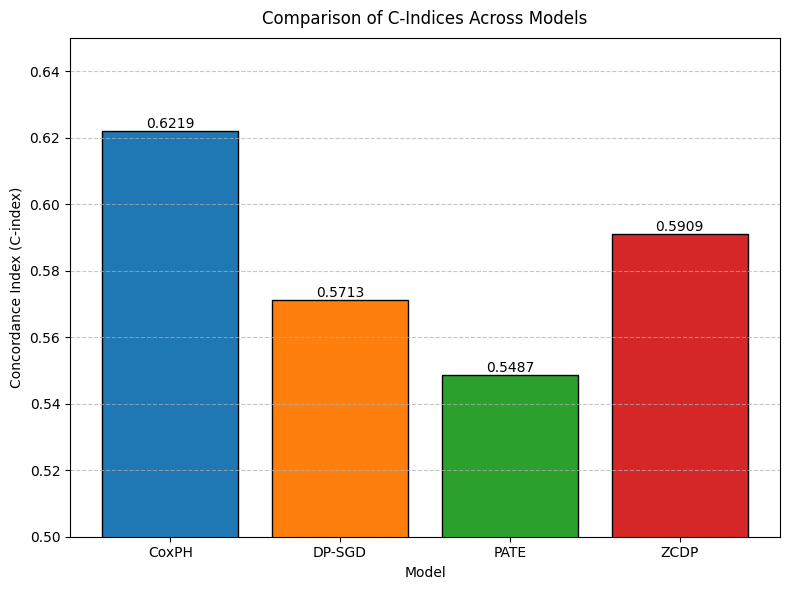

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['CoxPH', 'DP-SGD', 'PATE', 'ZCDP']
c_indices = [0.6219, 0.5713, 0.5487, 0.5909]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, c_indices, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black')
plt.title('Comparison of C-Indices Across Models', fontsize=12, pad=10)
plt.xlabel('Model', fontsize=10)
plt.ylabel('Concordance Index (C-index)', fontsize=10)
plt.ylim(0.5, 0.65)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

plt.tight_layout()

plt.savefig('cindex_bar_chart.png', dpi=300, bbox_inches='tight')

plt.show()

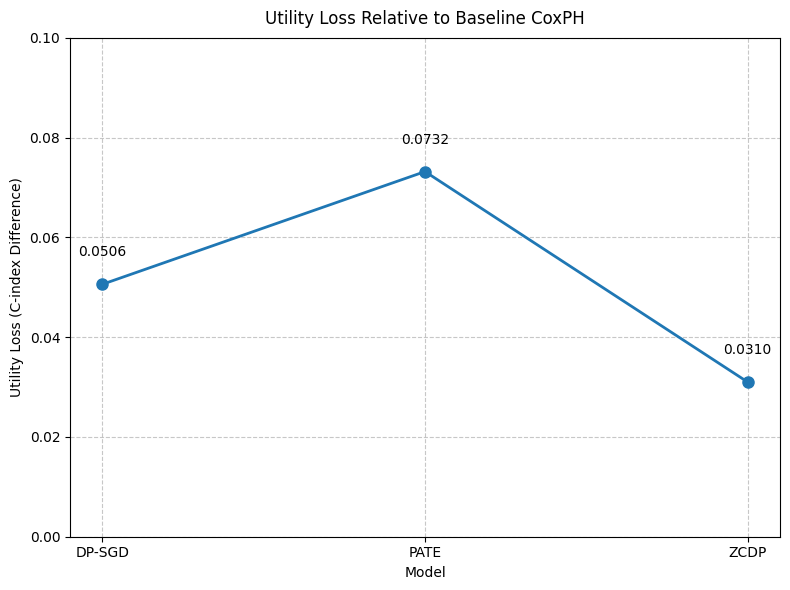

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['DP-SGD', 'PATE', 'ZCDP']
baseline_cindex = 0.6219
c_indices = [0.5713, 0.5487, 0.5909]
utility_losses = [baseline_cindex - c for c in c_indices]

plt.figure(figsize=(8, 6))
plt.plot(models, utility_losses, marker='o', color='#1f77b4', linewidth=2, markersize=8)
plt.title('Utility Loss Relative to Baseline CoxPH', fontsize=12, pad=10)
plt.xlabel('Model', fontsize=10)
plt.ylabel('Utility Loss (C-index Difference)', fontsize=10)
plt.ylim(0, 0.1)
plt.grid(True, linestyle='--', alpha=0.7)

for i, loss in enumerate(utility_losses):
    plt.text(models[i], loss + 0.005, f'{loss:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('utility_loss_line_plot.png', dpi=300, bbox_inches='tight')
plt.show()